In [25]:
# mount on google drive
from google.colab import drive
drive.mount('/content/drive/')


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
import os
os.chdir('/content/drive/MyDrive/satellite-altimetry-course')


In [3]:
# !pip install cartopy
# !pip install pyrsimg
# !apt-get install hdf5-tools


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 24.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  hdf5-tools
0 upgraded, 1 newly installed, 0 to remove and 45 not upgraded.
Need to get 347 kB of archives.
After this operation, 1,255 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 hdf5-tools amd64 1.10.7+repack-4ubuntu2 [347 kB]
Fetched 347 kB in 1s (458 kB/s)
Selecting previously unselected package hdf5-tools.
(Reading database ... 121752 files and directories currently installed.)
Preparing to unpack .../hdf5-tools_1.10.7+repack-4ubuntu2_amd64.deb ...
Unpacking hdf5-tools (1.10.7+repack-4ubuntu2) ...
Setting up hdf5-tools (1.10.7+repack-4ubuntu2) ...
Processing triggers for man-db (2.10.2-1) ...


### **ICESat-2数据处理**

In [4]:
import h5py
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from pyrsimg import readTiff, imgShow, second_to_dyr

In [5]:
path_atl06 = 'data/laser/processed_ATL06_20200806013350_06370802_006_01.h5'
path_rsimg = 'data/rsimg/s2_gla_region_20220707.tif'


In [6]:
!h5ls $path_atl06
# !h5ls $path_atl06/gt1l/land_ice_segments
# !h5ls $path_atl06/orbit_info


METADATA                 Group
ancillary_data           Group
gt1l                     Group
gt1r                     Group
gt2l                     Group
gt2r                     Group
gt3l                     Group
gt3r                     Group
orbit_info               Group
quality_assessment       Group


In [ ]:
vars_atl06 = {}
with h5py.File(path_atl06,'r') as setp_atl06:
    ## gt1l
    vars_atl06['lat_gt1l'] = setp_atl06['gt1l/land_ice_segments/latitude'][:]
    vars_atl06['lon_gt1l'] = setp_atl06['gt1l/land_ice_segments/longitude'][:]
    vars_atl06['elev_gt1l'] = setp_atl06['gt1l/land_ice_segments/h_li'][:]
    vars_atl06['time_delta_gt1l'] = setp_atl06['gt1l/land_ice_segments/delta_time'][:] ## Seconds start with the reference sdp time(2018-01-01).
    ### quality
    vars_atl06['qual_gt1l'] = setp_atl06['gt1l/land_ice_segments/atl06_quality_summary'][:]
    ## orbit information.
    vars_atl06['cycle'] = setp_atl06['orbit_info/cycle_number'][0]
    vars_atl06['track'] = setp_atl06['orbit_info/rgt'][0]
    vars_atl06['orient'] = setp_atl06['orbit_info/sc_orient'][0]

## 2. remote sensing image
rsimg = readTiff(path_rsimg)


### Time conversion

In [ ]:
time = second_to_dyr(vars_atl06['time_delta_gt1l'], time_start = '2018-01-01 00:00:00.0')
time


array([2020.5958093 , 2020.5958093 , 2020.5958093 , ..., 2020.59580949,
       2020.59580949, 2020.59580949])

### Data filtering

In [18]:
region = [94.56, 30.38, 95.04, 30.77]
## 排除异常点
ids_gt1l = np.where((vars_atl06['lat_gt1l']>region[1]) \
                    & (vars_atl06['lat_gt1l']<region[3]) \
                    & (vars_atl06['lon_gt1l']>region[0]) \
                    & (vars_atl06['lon_gt1l']<region[2]) \
                    & (vars_atl06['elev_gt1l']<9000))
lat_gt1l = vars_atl06['lat_gt1l'][ids_gt1l]
lon_gt1l = vars_atl06['lon_gt1l'][ids_gt1l]
elev_gt1l = vars_atl06['elev_gt1l'][ids_gt1l]
qual_gt1l = vars_atl06['qual_gt1l'][ids_gt1l]

## 选取质量好的数据
ids_good_gt1l = np.where((qual_gt1l==0))
lat_gt1l_filter = lat_gt1l[ids_good_gt1l]
lon_gt1l_filter = lon_gt1l[ids_good_gt1l]
elev_gt1l_filter = elev_gt1l[ids_good_gt1l]

print(vars_atl06['lat_gt1l'].shape)
print(lat_gt1l.shape)
print(lat_gt1l_filter.shape)



(1890,)
(1858,)
(1114,)


### Visualization

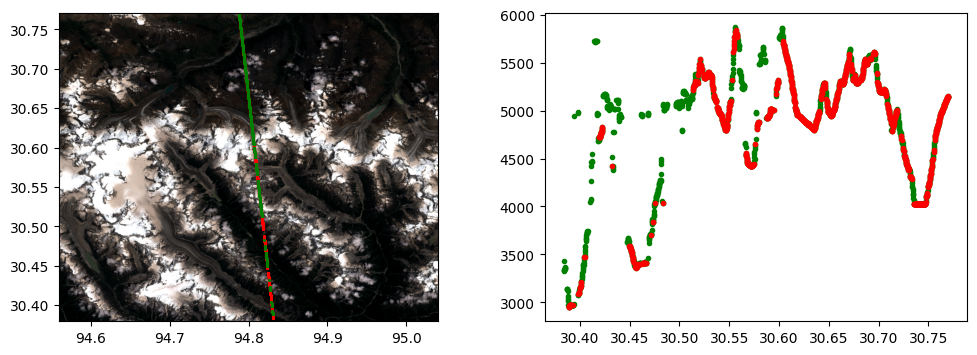

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
imgShow(rsimg.array, extent=rsimg.geoextent, clip_percent=5, ax=ax[0])
ax[0].scatter(x=lon_gt1l, y=lat_gt1l, s=1.5, color='red')
ax[0].scatter(x=lon_gt1l_filter, y=lat_gt1l_filter, s=1.5, color='green')
ax[1].plot(lat_gt1l, elev_gt1l, 'g.')
ax[1].plot(lat_gt1l_filter, elev_gt1l_filter, 'r.')


## 对所有波束数据进行数据

In [10]:
vars_atl06 = {}
beams = ['gt1l','gt1r','gt2l','gt2r','gt3l','gt3r']
with h5py.File(path_atl06,'r') as setp_atl06:
    for beam in beams:
        ## gt1l
        vars_atl06['lat_'+beam] = setp_atl06[beam+'/land_ice_segments/latitude'][:]
        vars_atl06['lon_'+beam] = setp_atl06[beam+'/land_ice_segments/longitude'][:]
        vars_atl06['elev_'+beam] = setp_atl06[beam+'/land_ice_segments/h_li'][:]
        vars_atl06['time_delta_'+beam] = setp_atl06[beam+'/land_ice_segments/delta_time'][:] ## Seconds start with the reference sdp time(2018-01-01).
        ### quality
        vars_atl06['qual_'+beam] = setp_atl06[beam+'/land_ice_segments/atl06_quality_summary'][:]
    ## orbit information.
    vars_atl06['cycle'] = setp_atl06['orbit_info/cycle_number'][0]
    vars_atl06['track'] = setp_atl06['orbit_info/rgt'][0]
    vars_atl06['orient'] = setp_atl06['orbit_info/sc_orient'][0]

## 2. remote sensing image
rsimg = readTiff(path_rsimg)



In [20]:
for beam in beams:
    vars_atl06['time_dyr'+beam] = second_to_dyr(vars_atl06['time_delta_gt1l'], time_start = '2018-01-01 00:00:00.0')


In [23]:
region = [94.56, 30.38, 95.04, 30.77]
processed_vars_atl06 = {}

for beam in beams:
    ## 排除异常点，及选取质量好的数据
    ids_beam = np.where((vars_atl06['lat_'+beam]>region[1]) \
                        & (vars_atl06['lat_'+beam]<region[3]) \
                        & (vars_atl06['lon_'+beam]>region[0]) \
                        & (vars_atl06['lon_'+beam]<region[2]) \
                        & (vars_atl06['elev_'+beam]<9000) \
                        & (vars_atl06['qual_'+beam]==0))
    processed_vars_atl06['lat_'+beam] = vars_atl06['lat_'+beam][ids_beam]
    processed_vars_atl06['lon_'+beam] = vars_atl06['lon_'+beam][ids_beam]
    processed_vars_atl06['elev_'+beam] = vars_atl06['elev_'+beam][ids_beam]
    processed_vars_atl06['time_dyr_'+beam] = vars_atl06['time_'+beam][ids_beam]

## orbit information
processed_vars_atl06['cycle'] = vars_atl06['cycle']
processed_vars_atl06['track'] = vars_atl06['track']
processed_vars_atl06['orient'] = vars_atl06['orient']



## write out to .h5 file.

In [24]:
# file_out = 'data/laser/isat2_gla_region.h5'
# with h5py.File(file_out, "w") as f_out:
#     [f_out.create_dataset(key, data=processed_vars_atl06[key]) for key in processed_vars_atl06.keys()]
#     print('written file:', (file_out))



written file: data/laser/isat2_gla_region.h5
